In [30]:
import pandas as pd

In [31]:
# Files to load
customer_data_to_load = "Downloads/data.csv"

In [32]:
# Read city_data_df = pd.read_csv(city_data_to_load)
customer_data_df = pd.read_csv(customer_data_to_load)
customer_data_df.head(10)

,\tEmail,Address,Avatar,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank TunnelWrightmouth, MI 82180-9605",Violet,12.66,39.58,4.08,587.95
1,hduke@hotmail.com,"4547 Archer CommonDiazchester, CA 06566-8576",DarkGreen,11.11,37.27,2.66,392.20
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582Cobbborough, DC ...",Bisque,11.33,37.11,4.10,487.55
3,riverarebecca@gmail.com,"1414 David ThroughwayPort Jason, OH 22070-1220",SaddleBrown,13.72,36.72,3.12,581.85
4,mstephens@davidson-herman.com,"14023 Rodriguez PassagePort Jacobville, PR 372...",MediumAquaMarine,12.80,37.54,4.45,599.41
5,alvareznancy@lucas.biz,"645 Martha Park Apt. 611Jeffreychester, MN 672...",FloralWhite,12.03,34.48,5.49,637.10
6,katherine20@yahoo.com,"68388 Reyes Lights Suite 692Josephbury, WV 922...",DarkSlateBlue,11.37,36.68,4.69,521.57
7,awatkins@yahoo.com,Unit 6538 Box 8980DPO AP 09026-4941,Aqua,12.35,37.37,4.43,549.90
8,vchurch@walter-martinez.com,"860 Lee KeyWest Debra, SD 97450-0495",Salmon,13.39,37.53,3.27,570.20
9,bonnie69@lin.biz,"PSC 2734, Box 5255APO AA 98456-7482",Brown,11.81,37.15,3.20,427.20


In [33]:
#check dataset structure
customer_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   	Email                500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Time on App           500 non-null    float64
 4   Time on Website       500 non-null    float64
 5   Length of Membership  500 non-null    float64
 6   Yearly Amount Spent   500 non-null    float64
dtypes: float64(4), object(3)
memory usage: 27.5+ KB


In [34]:
#Remove duplicate rows
customer_data_df = customer_data_df.drop_duplicates()

In [35]:
#Check duplicates removed
print("Total rows after removing duplicates:", len(customer_data_df))

Total rows after removing duplicates: 500


In [36]:
#Check Missing Values
customer_data_df.isnull().sum()

\tEmail                 0
Address                 0
Avatar                  0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

In [37]:
#Remove missing values
customer_data_df = customer_data_df.dropna()

In [38]:
customer_data_df.columns

Index(['\tEmail', 'Address', 'Avatar', 'Time on App', 'Time on Website',
       'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

In [39]:
customer_data_df.columns = customer_data_df.columns.str.strip()
customer_data_df.columns

Index(['Email', 'Address', 'Avatar', 'Time on App', 'Time on Website',
       'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

In [40]:
#Removing unneccesary columns
customer_data_df = customer_data_df.drop(["Email", "Address"], axis=1)

In [41]:
customer_data_df.columns

Index(['Avatar', 'Time on App', 'Time on Website', 'Length of Membership',
       'Yearly Amount Spent'],
      dtype='object')

In [42]:
#Save cleaned dataset
customer_data_df.to_csv("customer_data_clean.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [43]:
import os
os.getcwd()

'C:\\Users\\Administrator'

In [44]:
#Exploratory Data Analysis
import matplotlib.pyplot as plt
import seaborn as sns

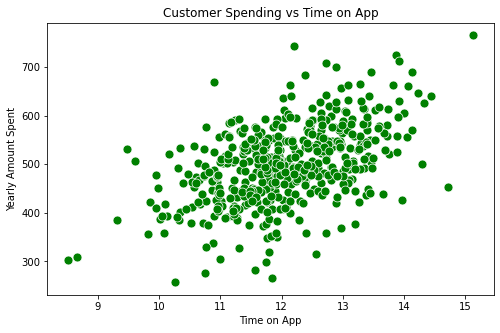

In [51]:
#Spending vs Time on App
plt.figure(figsize=(8,5))
sns.scatterplot(x='Time on App', y='Yearly Amount Spent', data=customer_data_df,color='green', s=80)
plt.title("Customer Spending vs Time on App")
plt.show()

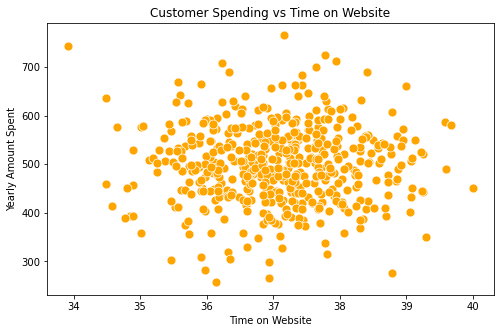

In [52]:
#Spending vs Website Usage
plt.figure(figsize=(8,5))
sns.scatterplot(x='Time on Website', y='Yearly Amount Spent', data=customer_data_df, color='orange', s=80)
plt.title("Customer Spending vs Time on Website")
plt.show()

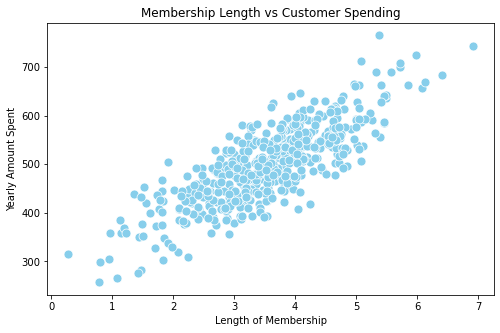

In [50]:
#Membership Length vs Spending
plt.figure(figsize=(8,5))
sns.scatterplot(x='Length of Membership', y='Yearly Amount Spent', data=customer_data_df, color='skyblue', s=80)
plt.title("Membership Length vs Customer Spending")
plt.show()

In [55]:
#Correlation Analysis
corr_matrix = customer_data_df.select_dtypes(include='number').corr()
corr_matrix

,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
Time on App,1.000000,0.082285,0.029240,0.499315
Time on Website,0.082285,1.000000,-0.047443,-0.002601
Length of Membership,0.029240,-0.047443,1.000000,0.809184
Yearly Amount Spent,0.499315,-0.002601,0.809184,1.000000


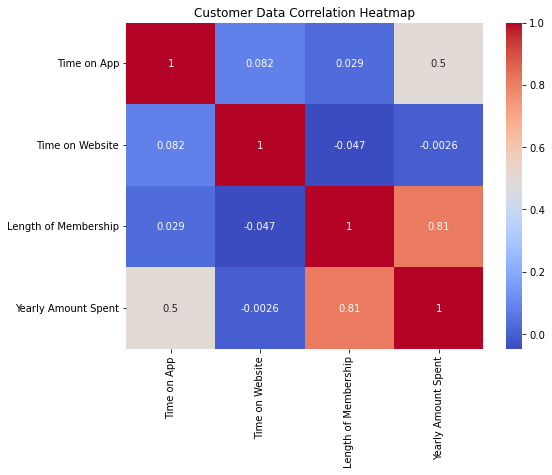

In [56]:
#Visualisation
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Customer Data Correlation Heatmap")
plt.show()

In [57]:
#SQL Analysis
import sqlite3

conn = sqlite3.connect("ecommerce.db")
customer_data_df.to_sql("customers", conn, if_exists="replace", index=False)


C:\Users\Administrator\anaconda3\envs\PythonData\lib\site-packages\pandas\core\generic.py:2882: UserWarning: The spaces in these column names will not be changed. In pandas versions < 0.14, spaces were converted to underscores.
  method=method,


In [58]:
#Average spending
query = """
SELECT AVG("Yearly Amount Spent") AS avg_spending
FROM customers
"""
pd.read_sql(query, conn)

,avg_spending
0,499.31424


In [59]:
#Highest spending customers
query = """
SELECT Avatar, "Yearly Amount Spent"
FROM customers
ORDER BY "Yearly Amount Spent" DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,Avatar,Yearly Amount Spent
0,OliveDrab,765.52
1,Wheat,744.22
2,SandyBrown,725.58
3,Gainsboro,712.40
4,Orchid,708.94
5,Wheat,700.92
6,DarkGray,689.79
7,Thistle,689.24
8,DimGray,684.16
9,Green,669.99


In [60]:
#Average Spending by Membership Length
query = """
SELECT 
ROUND(AVG("Yearly Amount Spent"),2) AS avg_spending,
ROUND(AVG("Length of Membership"),2) AS avg_membership
FROM customers
"""
pd.read_sql(query, conn)

,avg_spending,avg_membership
0,499.31,3.53


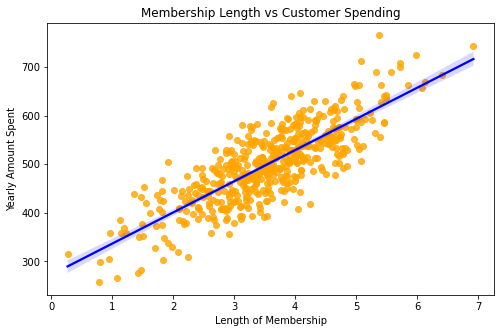

In [61]:
#Regression Plot
plt.figure(figsize=(8,5))
sns.regplot(x='Length of Membership', y='Yearly Amount Spent', data=customer_data_df, scatter_kws={'color':'orange'}, line_kws={'color':'blue'})
plt.title("Membership Length vs Customer Spending")
plt.xlabel("Length of Membership")
plt.ylabel("Yearly Amount Spent")
plt.show()

In [65]:
plt.savefig("customer_spending_regression.png")

<Figure size 432x288 with 0 Axes>

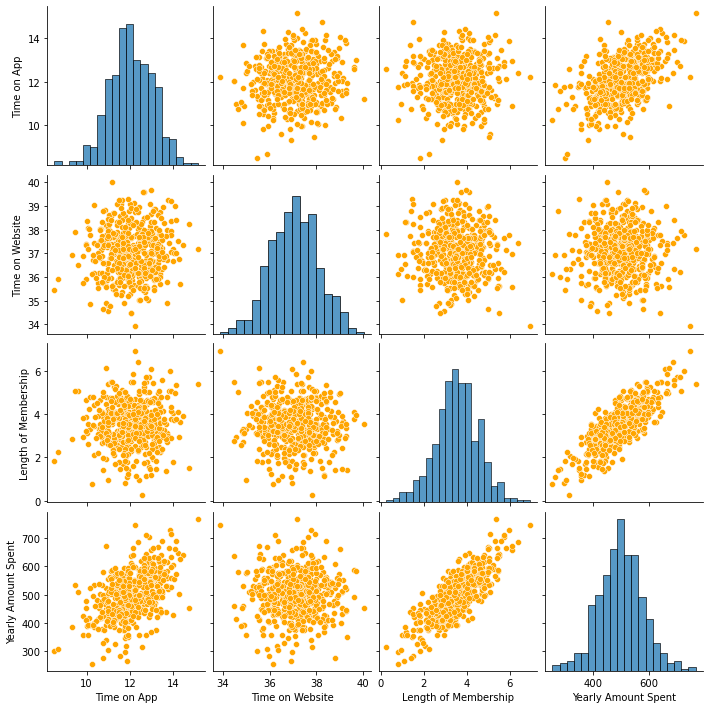

In [66]:
sns.pairplot(customer_data_df, plot_kws={'color':'orange'})
plt.show()

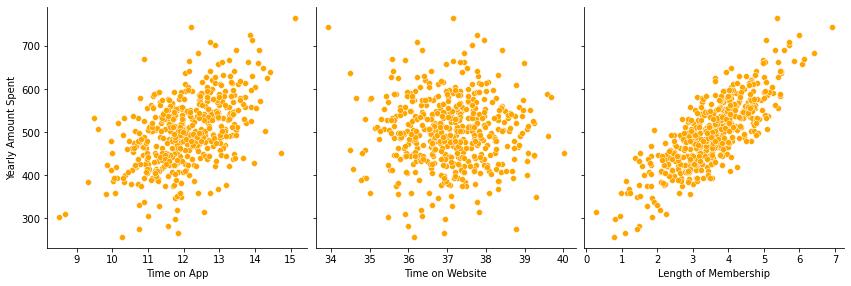

In [67]:
sns.pairplot(customer_data_df,
             x_vars=['Time on App','Time on Website','Length of Membership'],
             y_vars=['Yearly Amount Spent'],
             height=4,
             plot_kws={'color':'orange'})
plt.show()